In [1]:
from google.colab import files
files.upload()


Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"kulreenkaur","key":"ad8cd2165e6c57106d0389ab7fefa5e3"}'}

In [2]:
!mkdir -p ~/.kaggle
!mv "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!pip install -q kaggle


In [4]:
!kaggle datasets download -d muhammadzakria2001/baggage-xray-threats


Dataset URL: https://www.kaggle.com/datasets/muhammadzakria2001/baggage-xray-threats
License(s): MIT
100% 9.10G/9.11G [01:46<00:00, 85.5MB/s]
100% 9.11G/9.11G [01:46<00:00, 91.6MB/s]


In [5]:
!unzip -q baggage-xray-threats.zip


In [6]:
!ls


Augmented_Dataset  baggage-xray-threats.zip  sample_data


In [8]:
import os

base_path = '/content/Augmented_Dataset/GDXray'
image_dir = os.path.join(base_path, 'images')
mask_dir = os.path.join(base_path, 'masks')

# Confirm paths
print("Image samples:", os.listdir(image_dir)[:5])
print("Mask samples:", os.listdir(mask_dir)[:5])


Image samples: ['B0008_0183shifted10_0.jpg', 'B0051_0049flip1.jpg', 'B0049_0019scaled1.2.jpg', 'B0049_0039flip-1.jpg', 'B0046_0192shifted0_-10.jpg']
Mask samples: ['B0050_0034rotated45.png', 'B0046_0012shifted0_-10.png', 'B0008_0008scaled1.2.png', 'B0008_0136shifted10_0.png', 'B0051_0055rotated360.png']


In [9]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import random
from PIL import Image


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])
mask_paths  = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])

print("Total images:", len(image_paths))
print("Total masks :", len(mask_paths))

if image_paths and mask_paths:
    print("Example image path:", image_paths[0])
    print("Example mask path :", mask_paths[0])
else:
    print(" No images or masks found. Check the folder paths and file extensions.")

Total images: 11032
Total masks : 11032
Example image path: /content/Augmented_Dataset/GDXray/images/B0001_0001flip-1.jpg
Example mask path : /content/Augmented_Dataset/GDXray/masks/B0001_0001flip-1.png


In [12]:
from torchvision.transforms import functional as F

class XraySegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize both to 256x256
        image = image.resize((256, 256))
        mask = mask.resize((256, 256))

        # To tensor
        image = transforms.ToTensor()(image)
        mask = transforms.ToTensor()(mask)

        # Binarize mask: make everything > 0 as 1
        mask = (mask > 0).float()

        return image, mask

In [13]:

# Define transform if needed (can add augmentations later)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Correct instantiation using image_dir and mask_dir
dataset = XraySegmentationDataset(image_dir, mask_dir, transform=transform)

# Check one sample
img, mask = dataset[0]
print("Image shape:", img.shape)  # should be torch.Size([3, 256, 256])
print("Mask shape:", mask.shape)  # should be torch.Size([1, 256, 256])

_, mask = dataset[0]
print("Unique mask values:", torch.unique(mask))  # should be tensor([0., 1.])


Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Unique mask values: tensor([0., 1.])


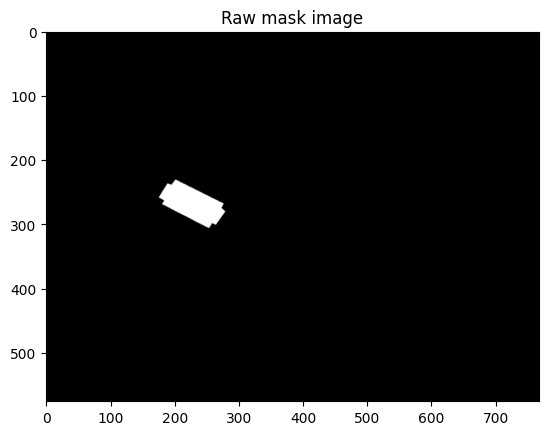

In [14]:

# Load mask using PIL, before transform
mask_path = os.path.join(mask_dir, dataset.masks[0])
mask_img = Image.open(mask_path).convert("L")
plt.imshow(np.array(mask_img), cmap='gray')
plt.title("Raw mask image")
plt.show()


In [15]:
print("Mask pixel values:", torch.unique(mask))
print("Mask max, min:", mask.max(), mask.min())


Mask pixel values: tensor([0., 1.])
Mask max, min: tensor(1.) tensor(0.)


In [16]:
from torch.utils.data import Subset

# Split indices for train/val/test (e.g., 70/15/15)
total_size = len(dataset)
indices = list(range(total_size))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

# Subset datasets
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Check
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 7722
Validation size: 1655
Test size: 1655


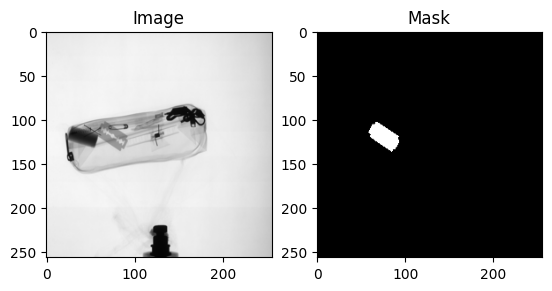

In [17]:

img, msk = dataset[0]
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title("Image")
plt.subplot(1, 2, 2)
plt.imshow(msk.squeeze(), cmap='gray')
plt.title("Mask")
plt.show()


In [18]:

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class MultiResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.final = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        d3 = self.up3(e4)
        d3 = self.dec3(torch.cat([e3, d3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([e2, d2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([e1, d1], dim=1))
        return torch.sigmoid(self.final(d1))


In [19]:
import torch.nn.functional as F

def dice_coef(y_true, y_pred, smooth=1.):
    y_pred = (y_pred > 0.5).float()
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def iou_score(y_true, y_pred, smooth=1):
    y_pred = (y_pred > 0.5).float()
    intersection = (y_true * y_pred).sum(dim=(2,3))
    union = y_true.sum(dim=(2,3)) + y_pred.sum(dim=(2,3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean()

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    bce = F.binary_cross_entropy(y_pred, y_true)
    dsc = dice_loss(y_true, y_pred)
    return bce + dsc


In [20]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, optimizer, num_epochs, device, patience=3):
    train_losses = []
    val_losses = []
    val_dices = []

    best_val_loss = float('inf')
    best_model_wts = None
    epochs_no_improve = 0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)  # sigmoid assumed inside model
            loss = combined_loss(masks, outputs)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(train_loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        dice_scores = []

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = combined_loss(masks, outputs)
                val_loss += loss.item()
                dice_scores.append(dice_coef(masks, outputs).item())

        avg_val_loss = val_loss / len(val_loader)
        avg_dice = sum(dice_scores) / len(dice_scores)

        val_losses.append(avg_val_loss)
        val_dices.append(avg_dice)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] => "
              f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, "
              f"Val Dice: {avg_dice:.4f}, LR: {current_lr:.6f}")

        # Step the scheduler
        scheduler.step(avg_val_loss)

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                model.load_state_dict(best_model_wts)
                break

    # Save best model
    torch.save(model.state_dict(), "best_model.pth")

    return train_losses, val_losses, val_dices, model

def validate_model(model, val_loader, device):
    model.eval()
    dices, ious = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            dices.append(dice_coef(masks, outputs).item())
            ious.append(iou_score(masks, outputs).item())
    return sum(dices)/len(dices), sum(ious)/len(ious)


In [21]:
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

# Define the hyperparameter search space
search_space = {
    'lr': (1e-5, 1e-2),           # continuous
    'base': [16, 32, 64],         # categorical
    'batch_size': [8, 16, 32],    # categorical
}

In [22]:
def fitness_function(hyperparams, model_class, train_dataset, val_dataset, device):
    # Decode hyperparams
    lr = hyperparams['lr']
    base = hyperparams['base']
    batch_size = hyperparams['batch_size']

    # Subset data for speed
    small_train = Subset(train_dataset, random.sample(range(len(train_dataset)), 500))
    small_val = Subset(val_dataset, random.sample(range(len(val_dataset)), 300))

    train_loader = DataLoader(small_train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(small_val, batch_size=batch_size, shuffle=False)

    # Initialize model and optimizer
    model = model_class(base=base).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Train for fixed epochs (10)
    for _ in range(10):
        model.train()
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = combined_loss(masks, outputs)
            loss.backward()
            optimizer.step()

    # Validation Dice
    model.eval()
    dice_scores = []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            dice_scores.append(dice_coef(masks, outputs).item())
    avg_dice = sum(dice_scores) / len(dice_scores)

    return 1 - avg_dice  # since lower fitness is better


In [23]:
def random_solution(search_space):
    return {
        'lr': 10 ** random.uniform(np.log10(search_space['lr'][0]), np.log10(search_space['lr'][1])),
        'base': random.choice(search_space['base']),
        'batch_size': random.choice(search_space['batch_size']),
    }

def pso_cuckoo_optimization(model_class, train_dataset, val_dataset, device, n_particles=3, n_iterations=1):
    particles = [random_solution(search_space) for _ in range(n_particles)]
    velocities = [{k: 0 for k in p} for p in particles]
    personal_best = particles.copy()
    personal_best_scores = [fitness_function(p, model_class, train_dataset, val_dataset, device) for p in particles]

    global_best = personal_best[np.argmin(personal_best_scores)]

    for iter in range(n_iterations):
        print(f"--- Iteration {iter+1}/{n_iterations} ---")
        for i in range(n_particles):
            # Update velocity and position (PSO step)
            for key in ['lr']:
                r1, r2 = random.random(), random.random()
                cognitive = r1 * (np.log10(personal_best[i][key]) - np.log10(particles[i][key]))
                social = r2 * (np.log10(global_best[key]) - np.log10(particles[i][key]))
                velocities[i][key] = 0.5 * velocities[i][key] + cognitive + social
                new_val = np.log10(particles[i][key]) + velocities[i][key]
                particles[i][key] = 10 ** new_val

            for key in ['base', 'batch_size']:
                if random.random() < 0.5:
                    particles[i][key] = personal_best[i][key]
                else:
                    particles[i][key] = global_best[key]

            # Apply Cuckoo mutation (random reinitialization with some probability)
            if random.random() < 0.25:
                particles[i] = random_solution(search_space)

            # Evaluate new solution
            new_score = fitness_function(particles[i], model_class, train_dataset, val_dataset, device)
            if new_score < personal_best_scores[i]:
                personal_best[i] = particles[i]
                personal_best_scores[i] = new_score

        # Update global best
        current_best_index = np.argmin(personal_best_scores)
        if personal_best_scores[current_best_index] < fitness_function(global_best, model_class, train_dataset, val_dataset, device):
            global_best = personal_best[current_best_index]

    return global_best


In [ ]:

best_hyperparams = pso_cuckoo_optimization(
    model_class=MultiResUNet,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    n_particles=3,
    n_iterations=3
)

print("Best hyperparameters found:", best_hyperparams)


--- Iteration 1/3 ---
--- Iteration 2/3 ---
--- Iteration 3/3 ---
Best hyperparameters found: {'lr': 4.16560464135079e-05, 'base': 64, 'batch_size': 16}


In [ ]:
final_batch_size = best_hyperparams['batch_size']
final_lr = best_hyperparams['lr']
final_base = best_hyperparams['base']
final_epochs = 10  

train_loader = DataLoader(train_dataset, batch_size=final_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=final_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=final_batch_size, shuffle=False)

final_model = MultiResUNet(base=final_base).to(device)
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=final_lr)

train_losses, val_losses, val_dices, best_model = train_model(
    final_model, train_loader, val_loader, final_optimizer, final_epochs, device, patience=3
)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/10] => Train Loss: 0.3049, Val Loss: 0.1883, Val Dice: 0.9446, LR: 0.000042


Epoch [2/10] => Train Loss: 0.1559, Val Loss: 0.1735, Val Dice: 0.9362, LR: 0.000042


Epoch [3/10] => Train Loss: 0.1168, Val Loss: 0.1278, Val Dice: 0.9507, LR: 0.000042


Epoch [4/10] => Train Loss: 0.0823, Val Loss: 0.2907, Val Dice: 0.8528, LR: 0.000042


...

Epoch [6/10] => Train Loss: 0.0588, Val Loss: 0.0543, Val Dice: 0.9785, LR: 0.000042


Epoch [7/10] => Train Loss: 0.0450, Val Loss: 0.0415, Val Dice: 0.9829, LR: 0.000042


Epoch [8/10] => Train Loss: 0.0411, Val Loss: 0.0452, Val Dice: 0.9799, LR: 0.000042


Epoch [9/10] => Train Loss: 0.0337, Val Loss: 0.0354, Val Dice: 0.9840, LR: 0.000042


Epoch [10/10] => Train Loss: 0.0288, Val Loss: 0.0342, Val Dice: 0.9839, LR: 0.000042


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, dataloader, device, threshold=0.5, plot_confusion=False):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = (outputs > threshold).float()

            # Squeeze channel dim and flatten
            y_true.extend(masks.squeeze(1).cpu().numpy().flatten())
            y_pred.extend(preds.squeeze(1).cpu().numpy().flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    dice = 2 * np.sum(y_true * y_pred) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)
    iou = np.sum((y_true * y_pred)) / (np.sum((y_true + y_pred) > 0) + 1e-7)

    print("\nEvaluation Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"Dice:      {dice:.4f}")
    print(f"IoU:       {iou:.4f}")

    
    if plot_confusion:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "dice": dice,
        "iou": iou,
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }


<ipython-input-27-b3c84ab38972>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load("best_model.pth"))



Evaluation Metrics:
Accuracy:  0.9941
Precision: 0.9933
Recall:    0.9717
F1-score:  0.9824
Dice:      0.9824
IoU:       0.9654


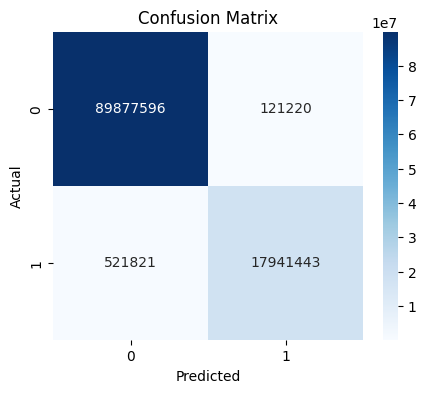

0.9823949437340769
[[89877596   121220]
 [  521821 17941443]]


In [ ]:
# Ensure model is loaded with best weights before evaluation
best_model.load_state_dict(torch.load("best_model.pth"))

# evaluate
results = evaluate_model(best_model, test_loader, device, plot_confusion=True)

print(results["f1"])
print(results["confusion_matrix"])

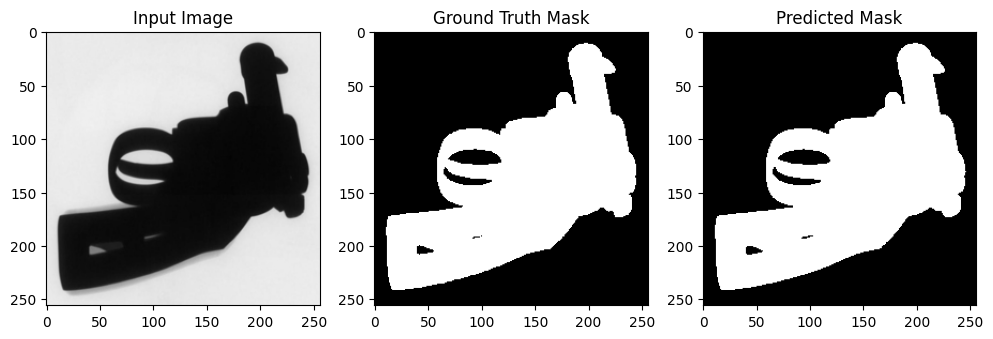

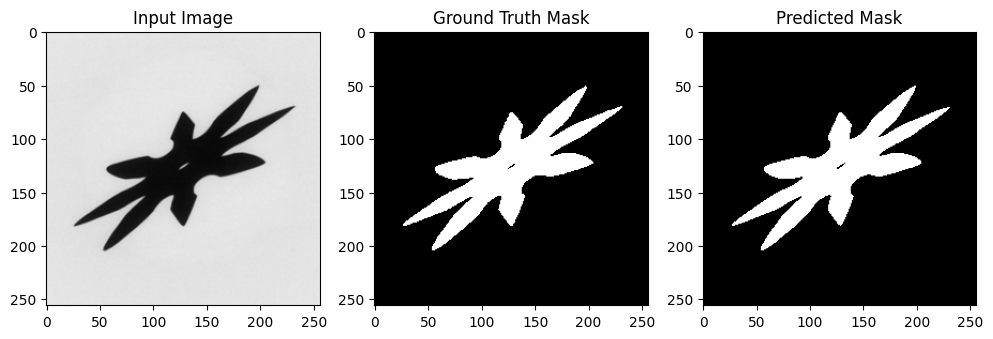

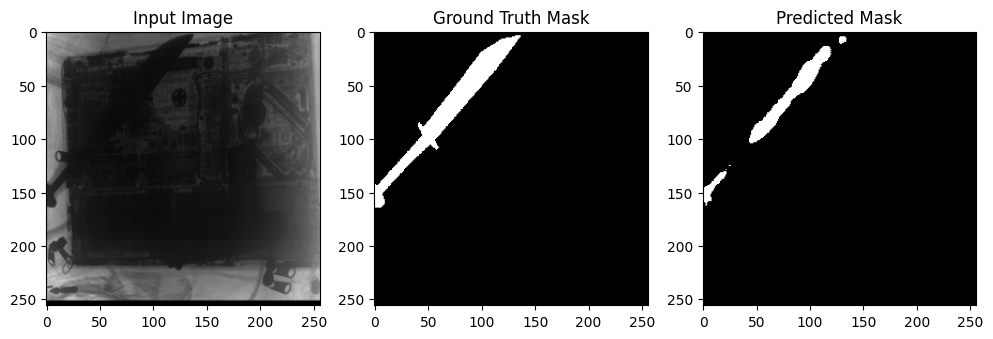

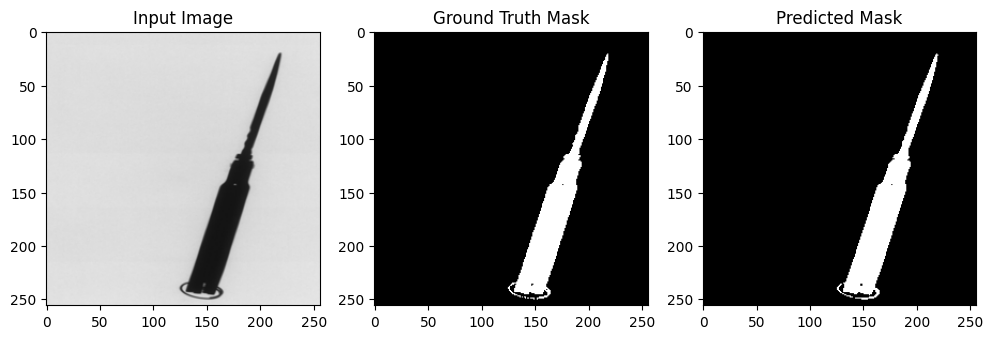

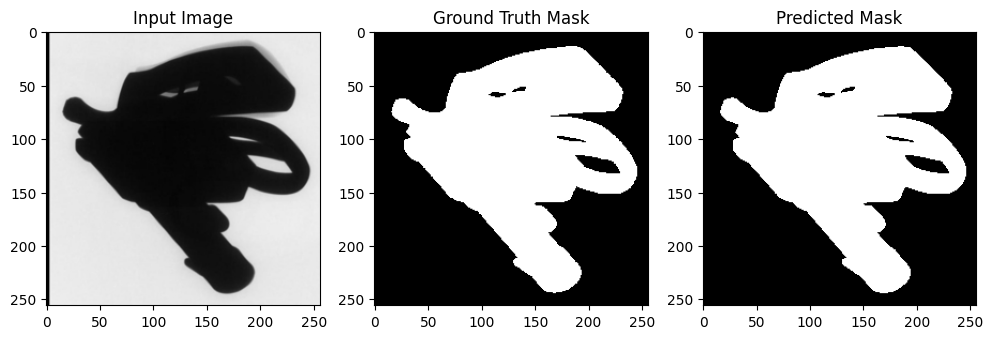

In [28]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    images_shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float()

            for i in range(images.shape[0]):
                if images_shown >= num_samples:
                    return
                img = images[i].cpu().permute(1, 2, 0).numpy()
                msk = masks[i].cpu().squeeze().numpy()
                prd = preds[i].cpu().squeeze().numpy()

                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(img)
                plt.title('Input Image')

                plt.subplot(1, 3, 2)
                plt.imshow(msk, cmap='gray')
                plt.title('Ground Truth Mask')

                plt.subplot(1, 3, 3)
                plt.imshow(prd, cmap='gray')
                plt.title('Predicted Mask')
                plt.show()

                images_shown += 1

# Call this after training
visualize_predictions(best_model, test_loader, device)


In [29]:
def plot_metrics(train_losses, val_losses, val_dices):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title("Loss over Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_dices, label='Val Dice')
    plt.title("Validation Dice Score")
    plt.legend()
    plt.show()


In [30]:
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
from math import pi

def plot_radar_chart(metrics_dict):
    labels = list(metrics_dict.keys())
    stats = list(metrics_dict.values())

    # Close the circle
    labels += [labels[0]]
    stats += [stats[0]]

    angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, stats, linewidth=2)
    ax.fill(angles, stats, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels[:-1])
    ax.set_yticklabels([])
    plt.title('Segmentation Metrics Radar Chart')
    plt.show()


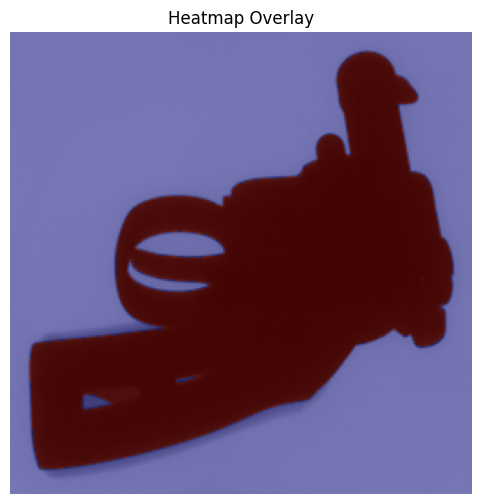

In [ ]:
def overlay_heatmap(image, prediction, alpha=0.5):
    image = image.cpu().permute(1, 2, 0).numpy()
    prediction = prediction.cpu().squeeze().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.imshow(prediction, cmap='jet', alpha=alpha)
    plt.title("Heatmap Overlay")
    plt.axis('off')
    plt.show()


best_model.eval()
images, masks = next(iter(test_loader))

with torch.no_grad():
    outputs = best_model(images.to(device))
    preds = (outputs > 0.5).float()

# Display heatmap for the first sample in the batch
overlay_heatmap(images[0], preds[0].cpu())


In [33]:
def plot_smoothed_loss(train_losses, val_losses, window_size=3):
    def smooth(data, window):
        return np.convolve(data, np.ones(window)/window, mode='valid')

    smooth_train = smooth(train_losses, window_size)
    smooth_val = smooth(val_losses, window_size)

    plt.figure(figsize=(8, 5))
    plt.plot(smooth_train, label='Train Loss (Smoothed)')
    plt.plot(smooth_val, label='Val Loss (Smoothed)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Smoothed Loss Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


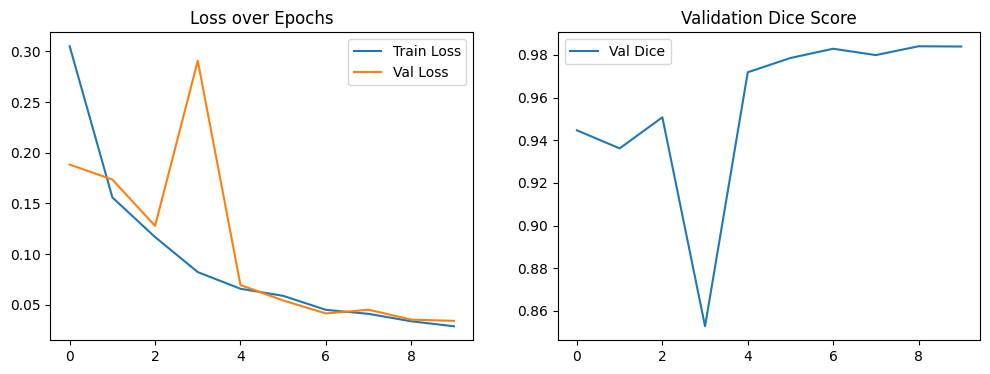

In [39]:
plot_metrics(train_losses, val_losses, val_dices)


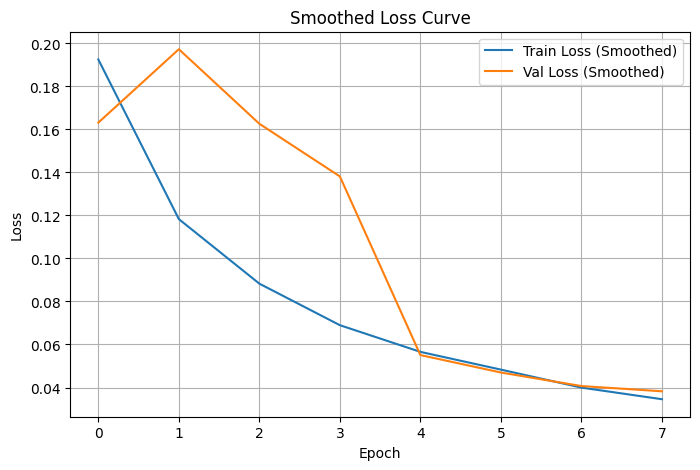

In [40]:
plot_smoothed_loss(train_losses, val_losses, window_size=3)

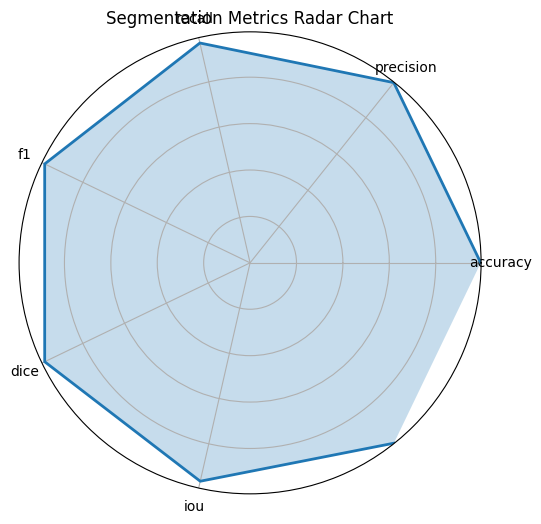

In [41]:
plot_radar_chart({k: v for k, v in results.items() if isinstance(v, float)})

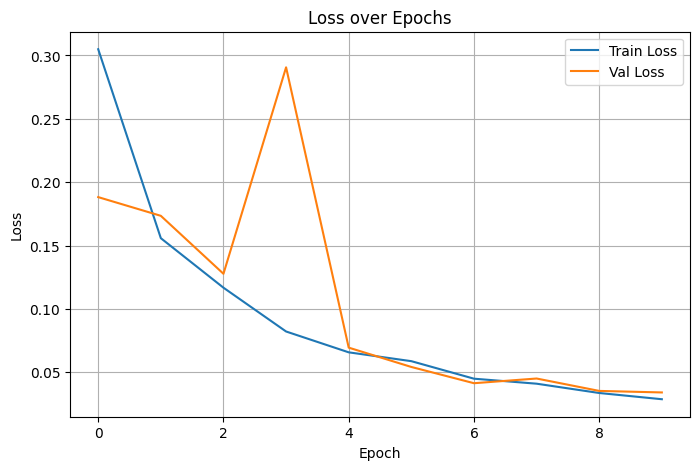

In [42]:
plot_loss_curve(train_losses, val_losses)